In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Reproducibility
np.random.seed(42)

In [3]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [4]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [5]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [ ]:
# =========================================
# Truth is the constraint — fit forecast to it
# =========================================
scale = 6

ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [ ]:
ds_fc

: 

: 

In [8]:
ds_tr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      46848 | 0.02738%


: 

: 

In [ ]:
def count_nan_per_time(ds, var):
    data = ds[var]

    spatial_dims = [d for d in data.dims if d != "time"]

    nan_count = data.isnull().sum(dim=spatial_dims)

    result = nan_count.to_dataframe(name="nan_count")
    result = result[result["nan_count"] > 0]

    print(result.head(20))

    return result

nan_summary = count_nan_per_time(ds_fc, "10m_u_component_of_wind")

# Get worst timestep (most NaNs)
worst_time = nan_summary["nan_count"].idxmax()

print("Worst timestep:", worst_time)

sample = ds_fc["10m_u_component_of_wind"].sel(time=worst_time)

print(sample)

            nan_count
time                 
2019-10-17      46848
Worst timestep: 2019-10-17 00:00:00
<xarray.DataArray '10m_u_component_of_wind' (prediction_timedelta: 61,
                                             longitude: 32, latitude: 24)> Size: 187kB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 488B 00:00:0..

#### Drop lead 0
because total precipitation in lead 0 is nan

In [ ]:
ds_fc = ds_fc.sel(prediction_timedelta=slice(np.timedelta64(1,'D'), None))

In [ ]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      43776 | 0.02738%
10m_v_component_of_wind        | NaNs:      43776 | 0.02738%
2m_temperature                 | NaNs:      43776 | 0.02738%
total_precipitation_24hr       | NaNs:      43776 | 0.02738%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [ ]:
def check_fully_missing_timesteps(ds, name):
    print(f"\n==== Fully Missing Timesteps: {name} ====")
    for var in ds.data_vars:
        data = ds[var]
        # Collapse spatial dims
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)
        n_missing = missing_time.sum().item()
        print(f"{var:30s} | fully-missing timesteps: {n_missing}")

check_fully_missing_timesteps(ds_fc, "Forecast")
check_fully_missing_timesteps(ds_tr, "Truth")


==== Fully Missing Timesteps: Forecast ====
10m_u_component_of_wind        | fully-missing timesteps: 1
10m_v_component_of_wind        | fully-missing timesteps: 1
2m_temperature                 | fully-missing timesteps: 1
total_precipitation_24hr       | fully-missing timesteps: 1

==== Fully Missing Timesteps: Truth ====
10m_u_component_of_wind        | fully-missing timesteps: 0
10m_v_component_of_wind        | fully-missing timesteps: 0
2m_temperature                 | fully-missing timesteps: 0
total_precipitation_24hr       | fully-missing timesteps: 0


In [ ]:
def find_missing_timesteps(ds):
    for var in ds.data_vars:
        data = ds[var]
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)

        missing_times = ds.time.where(missing_time, drop=True)

        print(f"\nVariable: {var}")
        print("Missing times:")
        print(missing_times.values)

find_missing_timesteps(ds_fc)


Variable: 10m_u_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 10m_v_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 2m_temperature
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: total_precipitation_24hr
Missing times:
['2019-10-17T00:00:00.000000000']


In [ ]:
# Auto-detect and drop ALL fully-missing timesteps (not hardcoded)
all_missing = set()
for var in ds_fc.data_vars:
    data = ds_fc[var]
    spatial_dims = [d for d in data.dims if d != "time"]
    missing_mask = data.isnull().all(dim=spatial_dims)
    missing_times = ds_fc.time.where(missing_mask, drop=True).values
    all_missing.update(missing_times)

all_missing = sorted(all_missing)
print(f"Dropping {len(all_missing)} fully-missing timesteps: {all_missing}")

if len(all_missing) > 0:
    ds_fc = ds_fc.drop_sel(time=all_missing)
    ds_tr = ds_tr.drop_sel(time=all_missing)

Dropping 1 fully-missing timesteps: [np.datetime64('2019-10-17T00:00:00.000000000')]


In [ ]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Temporal Allignment data

In [ ]:
# ==============================
# CONFIG
# ==============================
lead_days = 1
lead_td = np.timedelta64(lead_days, "D")

# ==============================
# 1️⃣ Lead selection
# ==============================
ds_fc_lead = ds_fc.sel(prediction_timedelta=lead_td)

# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc_lead.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc_lead = ds_fc_lead.assign_coords(valid_time=valid_time)
ds_fc_lead = ds_fc_lead.sel(valid_time=common_times)
ds_fc_lead = ds_fc_lead.assign_coords(time=ds_fc_lead.valid_time)
ds_fc_lead = ds_fc_lead.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc_lead.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc_lead.time),
      len(ds_fc_lead.latitude),
      len(ds_fc_lead.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3648
Forecast time == Truth time: True
Forecast shape: 3648 24 32
Truth shape: 3648 144 192


## Data model preparation

### Regrid Dataset

In [ ]:
import xesmf as xe

# ==============================
# 6️⃣ Regrid forecast to truth grid
# ==============================

# xesmf needs 'lat'/'lon' naming (not 'latitude'/'longitude')
ds_fc_regrid_in = ds_fc_lead.rename({"latitude": "lat", "longitude": "lon"})
ds_tr_regrid_in = ds_tr_aligned.rename({"latitude": "lat", "longitude": "lon"})

# Build regridder (bilinear is standard for continuous fields like temp/precip)
# periodic=False because this is a regional domain (Indonesia), NOT a global grid
regridder = xe.Regridder(
    ds_fc_regrid_in,
    ds_tr_regrid_in,
    method="bilinear",
    periodic=False,      # regional domain — do NOT wrap longitudes
)

# Apply — xesmf handles the time dimension automatically
ds_fc_regridded = regridder(ds_fc_regrid_in, keep_attrs=True)

# Rename back to original conventions
ds_fc_regridded = ds_fc_regridded.rename({"lat": "latitude", "lon": "longitude"})

print("Regridded forecast shape:",
      len(ds_fc_regridded.time),
      len(ds_fc_regridded.latitude),
      len(ds_fc_regridded.longitude))
# Expected: 3648 144 192

/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Regridded forecast shape: 3648 144 192


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Reproducibility
tf.random.set_seed(42)

# ==============================
# 7️⃣ Extract numpy arrays
# ==============================
# Explicitly define variable order to guarantee X/y channel alignment
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack variables → (T, H, W, C)  where C = num variables
X = np.stack([ds_fc_regridded[v].values for v in VARS], axis=-1).astype(np.float32)
y = np.stack([ds_tr_aligned[v].values   for v in VARS], axis=-1).astype(np.float32)

print("X shape (input):", X.shape)   # (3648, 144, 192, 4)
print("y shape (target):", y.shape)  # (3648, 144, 192, 4)

# ==============================
# 7.5 Log-transform precipitation BEFORE normalisation
# ==============================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p — X TP min/max: {X[..., TP_IDX].min():.4f} / {X[..., TP_IDX].max():.4f}")
print(f"Before log1p — y TP min/max: {y[..., TP_IDX].min():.4f} / {y[..., TP_IDX].max():.4f}")

X[..., TP_IDX] = np.log1p(np.clip(X[..., TP_IDX], 0, None))  # clip negatives (rounding artifacts)
y[..., TP_IDX] = np.log1p(np.clip(y[..., TP_IDX], 0, None))

print(f"After  log1p — X TP min/max: {X[..., TP_IDX].min():.4f} / {X[..., TP_IDX].max():.4f}")
print(f"After  log1p — y TP min/max: {y[..., TP_IDX].min():.4f} / {y[..., TP_IDX].max():.4f}")

# ==============================
# 8️⃣ Normalize per-variable (z-score) — separate stats for X and y
# ==============================
N = len(X)
n_train = int(N * 0.7)
n_val   = int(N * 0.15)

# Split first (temporal order preserved)
X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

# Compute stats from training split ONLY — separately for X and y
X_mean = X_train.mean(axis=(0, 1, 2), keepdims=True)  # (1, 1, 1, 4)
X_std  = X_train.std( axis=(0, 1, 2), keepdims=True)

y_mean = y_train.mean(axis=(0, 1, 2), keepdims=True)
y_std  = y_train.std( axis=(0, 1, 2), keepdims=True)

# Normalise
X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

y_train = (y_train - y_mean) / y_std
y_val   = (y_val   - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std

# Save both sets of stats for inference denormalisation
# NOTE: remember to expm1() after denormalising the TP channel
norm_stats = {
    "X_mean": X_mean, "X_std": X_std,
    "y_mean": y_mean, "y_std": y_std,
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,  # reminder for inference
}
np.save("norm_stats.npy", norm_stats)

print(f"\nTrain : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"X mean/std per var: {X_mean.squeeze().round(4)} / {X_std.squeeze().round(4)}")
print(f"y mean/std per var: {y_mean.squeeze().round(4)} / {y_std.squeeze().round(4)}")

2026-03-04 08:34:35.471113: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 08:34:35.484792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772613275.499581     118 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772613275.504266     118 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 08:34:35.519885: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

X shape (input): (3648, 144, 192, 4)
y shape (target): (3648, 144, 192, 4)

Before log1p — X TP min/max: 0.0000 / 0.2689
Before log1p — y TP min/max: -0.0000 / 0.5992
After  log1p — X TP min/max: 0.0000 / 0.2382
After  log1p — y TP min/max: 0.0000 / 0.4695

Train : (2553, 144, 192, 4) | Val : (547, 144, 192, 4) | Test : (548, 144, 192, 4)
X mean/std per var: [-1.385000e+00  3.392000e-01  1.216957e+02  4.500000e-03] / [3.55330e+00 2.75220e+00 9.06081e+01 7.10000e-03]
y mean/std per var: [-1.275100e+00  2.156000e-01  1.216957e+02  4.800000e-03] / [3.66520e+00 3.06310e+00 9.50021e+01 9.50000e-03]


In [ ]:
# ==============================
# 9️⃣ Build tf.data pipelines (CPU-resident)
# ==============================
BATCH_SIZE = 16       # smaller batch → better gradient estimate & regularisation
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(X, y, shuffle=False):
    # Wrap in a generator — data stays in CPU RAM, batches are streamed to GPU
    def generator():
        for i in range(len(X)):
            yield X[i], y[i]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=X.shape[1:], dtype=tf.float32),  # (144, 192, 4)
            tf.TensorSpec(shape=y.shape[1:], dtype=tf.float32),
        )
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=512, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

# Sanity check
for xb, yb in train_ds.take(1):
    print("Batch X:", xb.shape)
    print("Batch y:", yb.shape)

I0000 00:00:1772613294.641301     118 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43470 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:06:10.0, compute capability: 8.9


Batch X: (16, 144, 192, 4)
Batch y: (16, 144, 192, 4)


2026-03-04 08:34:56.649298: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# ==============================
# 🔟 UNet definition (improved)
# ==============================
from tensorflow.keras import layers, Model
import tensorflow as tf

def conv_block(x, filters, dropout_rate=0.1):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x

def unet(input_shape=(144, 192, 4), n_vars=4):
    inp = layers.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inp, 32,  dropout_rate=0.0)  # no dropout on first block
    p1 = layers.MaxPooling2D()(c1)               # 72×96

    c2 = conv_block(p1,  64,  dropout_rate=0.1)
    p2 = layers.MaxPooling2D()(c2)               # 36×48

    c3 = conv_block(p2,  128, dropout_rate=0.1)
    p3 = layers.MaxPooling2D()(c3)               # 18×24

    # Bottleneck
    b  = conv_block(p3,  256, dropout_rate=0.2)

    # Decoder
    u3 = layers.UpSampling2D(interpolation="bilinear")(b)
    u3 = layers.Concatenate()([u3, c3])
    u3 = conv_block(u3, 128, dropout_rate=0.1)

    u2 = layers.UpSampling2D(interpolation="bilinear")(u3)
    u2 = layers.Concatenate()([u2, c2])
    u2 = conv_block(u2, 64, dropout_rate=0.1)

    u1 = layers.UpSampling2D(interpolation="bilinear")(u2)
    u1 = layers.Concatenate()([u1, c1])
    u1 = conv_block(u1, 32, dropout_rate=0.0)

    out = layers.Conv2D(n_vars, 1, activation="linear")(u1)
    return Model(inp, out)

# ==============================
# Loss: MSE + gradient penalty
# (penalises spatially blurry predictions)
# ==============================
def gradient_loss(y_true, y_pred):
    dy_true = y_true[:, 1:, :, :] - y_true[:, :-1, :, :]
    dx_true = y_true[:, :, 1:, :] - y_true[:, :, :-1, :]
    dy_pred = y_pred[:, 1:, :, :] - y_pred[:, :-1, :, :]
    dx_pred = y_pred[:, :, 1:, :] - y_pred[:, :, :-1, :]
    return tf.reduce_mean(tf.abs(dy_true - dy_pred)) + \
           tf.reduce_mean(tf.abs(dx_true - dx_pred))

def combined_loss(y_true, y_pred, alpha=0.8, beta=0.2):
    return alpha * tf.reduce_mean(tf.square(y_true - y_pred)) + \
           beta  * gradient_loss(y_true, y_pred)

model = unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # slightly lower LR for stability
    loss=combined_loss,
    metrics=["mae"],
)
model.summary()

# ==============================
# Train
# ==============================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras", monitor="val_loss", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.CSVLogger("training_log.csv"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 144, 192,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 144, 192,  │      1,152 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 144, 192,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 144, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 144, 192,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 192,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 144, 192,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 72, 96,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 72, 96,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 96,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 72, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 72, 96,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 96,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 72, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 72, 96,    │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 36, 48,    │          0 │ spatial_dropout2… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 36, 48,    │     73,728 │ max_pooling2d_1[

 Total params: 1,951,492 (7.44 MB)

 Trainable params: 1,948,676 (7.43 MB)

 Non-trainable params: 2,816 (11.00 KB)

...

160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1417 - mae: 0.2064 - val_loss: 0.1662 - val_mae: 0.2122 - learning_rate: 1.2500e-04
Epoch 24/100
158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1403 - mae: 0.2073

2026-03-04 08:37:11.415489: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 3002933625772233541
2026-03-04 08:37:11.415602: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 5210759833624048668


160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1419 - mae: 0.2076 - val_loss: 0.1669 - val_mae: 0.2138 - learning_rate: 1.2500e-04
Epoch 25/100


2026-03-04 08:37:11.836001: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 3002933625772233541
2026-03-04 08:37:11.836123: I tensorflow/core/framework/local_rendezvous.cc:424] Local rendezvous recv item cancelled. Key hash: 5210759833624048668


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1384 - mae: 0.2044
Epoch 25: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1399 - mae: 0.2045 - val_loss: 0.1674 - val_mae: 0.2133 - learning_rate: 1.2500e-04
Epoch 26/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1386 - mae: 0.2043 - val_loss: 0.1667 - val_mae: 0.2119 - learning_rate: 6.2500e-05


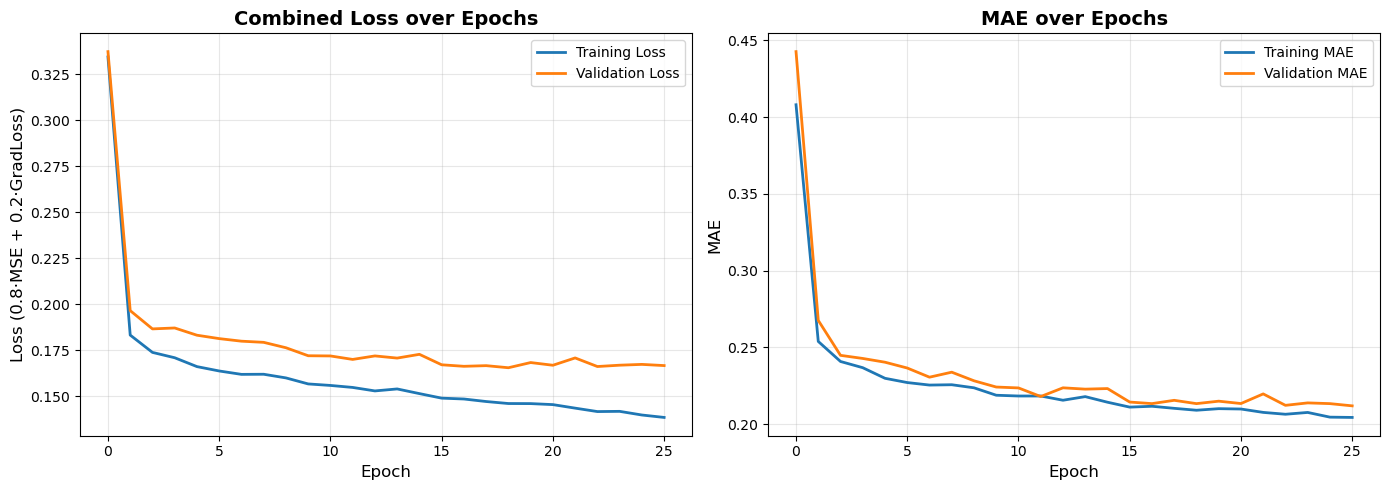


Final Training Loss: 0.138566
Final Validation Loss: 0.166719
Final Training MAE: 0.204339
Final Validation MAE: 0.211883


In [ ]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss (combined = 0.8*MSE + 0.2*gradient_loss)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (0.8·MSE + 0.2·GradLoss)', fontsize=12)
ax1.set_title('Combined Loss over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: MAE metric
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2)
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('MAE over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Loss: {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")
print(f"Final Training MAE: {history.history['mae'][-1]:.6f}")
print(f"Final Validation MAE: {history.history['val_mae'][-1]:.6f}")

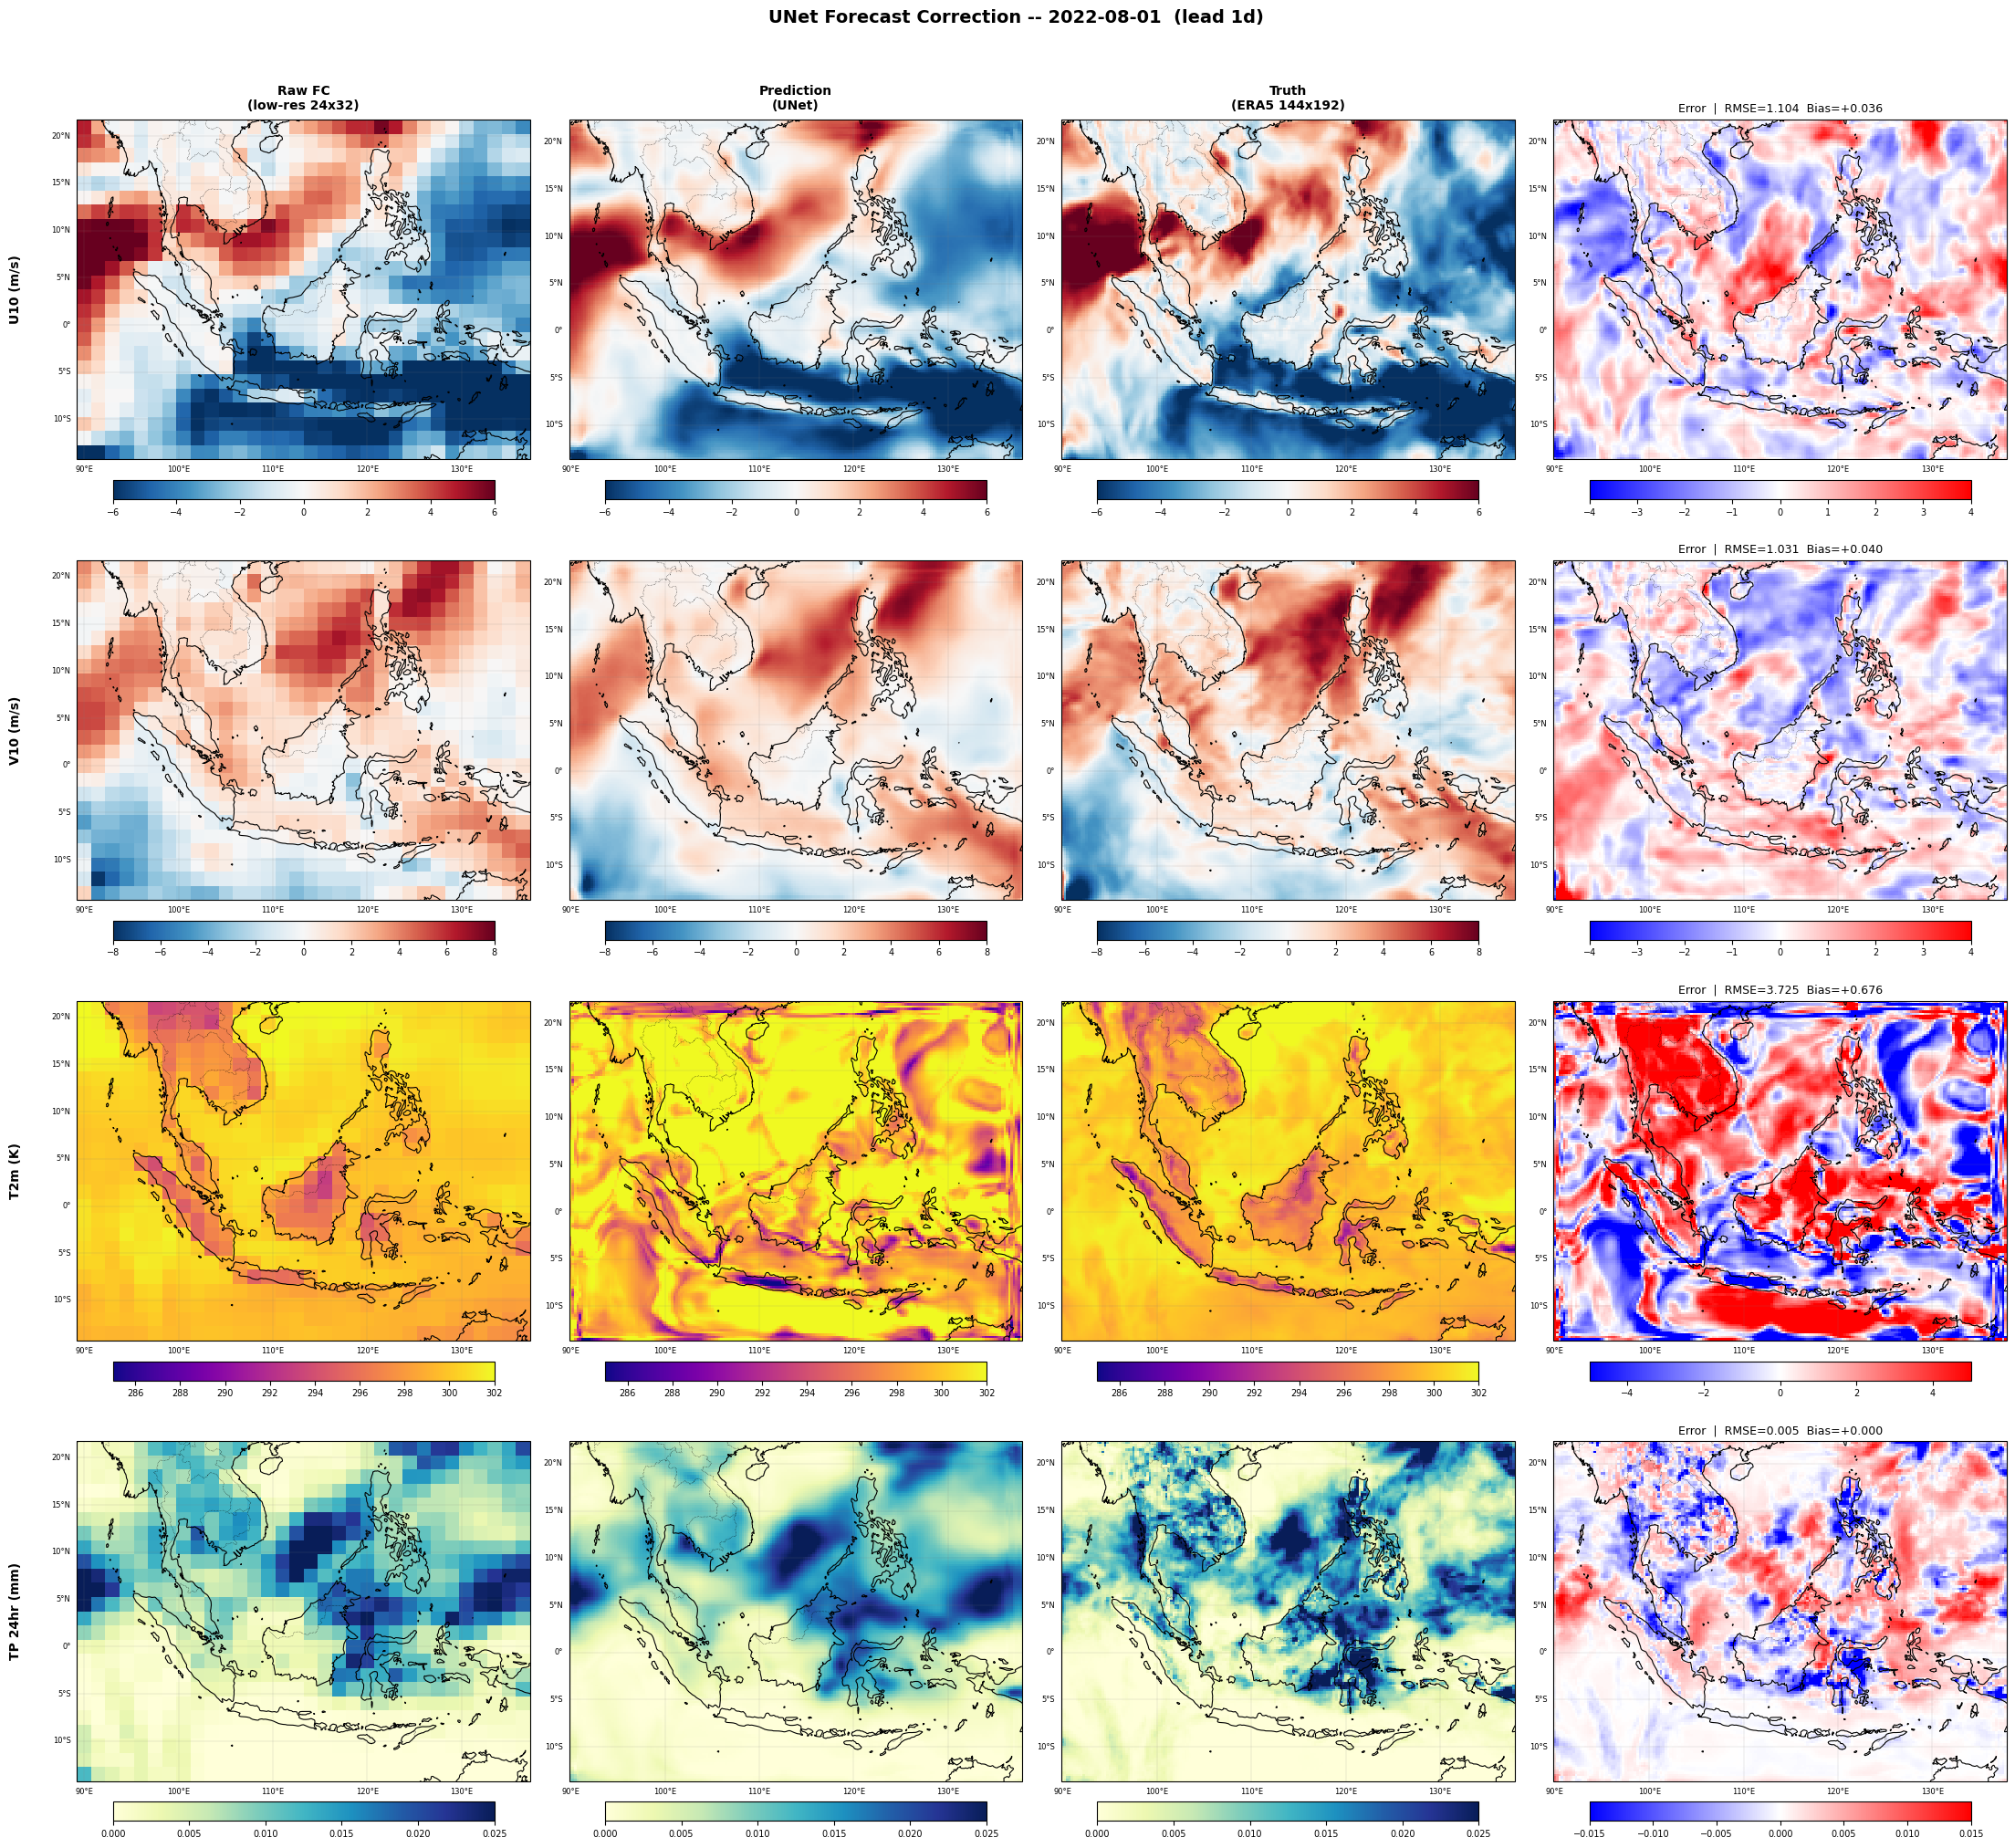

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
VAR_KEYS   = VARS

target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

test_times = ds_tr_aligned.time.values[n_train + n_val:]
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(f"{target_date} not found in test set.")
idx = idx[0]

raw_fc = np.stack(
    [ds_fc_lead[v].isel(time=n_train + n_val + idx).values for v in VAR_KEYS],
    axis=-1
).astype(np.float32)
if raw_fc.shape[0] == len(ds_fc_lead.longitude) and raw_fc.shape[1] == len(ds_fc_lead.latitude):
    raw_fc = raw_fc.transpose(1, 0, 2)
lats_lr = ds_fc_lead.latitude.values
lons_lr = ds_fc_lead.longitude.values

norm_stats = np.load("norm_stats.npy", allow_pickle=True).item()
X_mu  = norm_stats["X_mean"].squeeze()
X_sig = norm_stats["X_std"].squeeze()
y_mu  = norm_stats["y_mean"].squeeze()
y_sig = norm_stats["y_std"].squeeze()

def denormalize(arr, mu, sig, tp_idx=TP_IDX):
    out = arr * sig + mu
    out[..., tp_idx] = np.expm1(out[..., tp_idx])
    return out

x_norm    = X_test[idx]
y_norm    = y_test[idx]
pred_norm = model.predict(x_norm[np.newaxis], verbose=0)[0]

y_plot    = denormalize(y_norm.copy(),    y_mu, y_sig)
pred_plot = denormalize(pred_norm.copy(), y_mu, y_sig)

if pred_plot.shape[0] == len(ds_tr_aligned.longitude):
    y_plot    = y_plot.transpose(1, 0, 2)
    pred_plot = pred_plot.transpose(1, 0, 2)

lats_hr = ds_tr_aligned.latitude.values
lons_hr = ds_tr_aligned.longitude.values

proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS)

col_titles = [
    "Raw FC\n(low-res 24x32)",
    "Prediction\n(UNet)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    raw_v  = raw_fc[..., v]
    pred_v = pred_plot[..., v]
    true_v = y_plot[..., v]
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges (matching SRUNet notebook)
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="auto",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"UNet Forecast Correction -- {str(target_date)[:10]}  (lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"unet_eval_full_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

## Aggregate Test Set Evaluation
Per-variable RMSE, MAE, Bias, and Correlation over the **entire** test split — not just one sample.

In [ ]:
# ==============================
# Aggregate test-set evaluation
# ==============================
for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[..., v_idx]
    true_v = y_true_phys[..., v_idx]
    base_v = x_base_phys[..., v_idx]

    # Remove NaNs without flattening
    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v = np.where(mask, pred_v, np.nan)
    true_v = np.where(mask, true_v, np.nan)
    base_v = np.where(mask, base_v, np.nan)

    # Metrics (per-sample spatial, then averaged)
    rmse = np.nanmean(np.sqrt(np.nanmean((pred_v - true_v) ** 2, axis=(1, 2))))
    mae  = np.nanmean(np.nanmean(np.abs(pred_v - true_v), axis=(1, 2)))
    bias = np.nanmean(np.nanmean(pred_v - true_v, axis=(1, 2)))

    p_mean = np.nanmean(pred_v, axis=(1, 2), keepdims=True)
    t_mean = np.nanmean(true_v, axis=(1, 2), keepdims=True)
    p_anom = pred_v - p_mean
    t_anom = true_v - t_mean
    num = np.nansum(p_anom * t_anom, axis=(1, 2))
    den = np.sqrt(np.nansum(p_anom ** 2, axis=(1, 2)) * np.nansum(t_anom ** 2, axis=(1, 2)))
    corr_per = np.divide(num, den, out=np.full_like(num, np.nan, dtype=np.float64), where=den > 0)
    corr = np.nanmean(corr_per)

    # Baseline RMSE
    rmse_base = np.nanmean(np.sqrt(np.nanmean((base_v - true_v) ** 2, axis=(1, 2))))
print(f"{'Variable':30s} | {'RMSE':>8s} | {'MAE':>8s} | {'Bias':>8s} | {'Corr':>8s} | {'Baseline RMSE':>14s} | {'Skill':>8s}")
print("=" * 80)

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[..., v_idx].flatten()
    true_v = y_true_phys[..., v_idx].flatten()
    base_v = x_base_phys[..., v_idx].flatten()

    # Remove NaN pairs
    mask = ~(np.isnan(pred_v) | np.isnan(true_v) | np.isnan(base_v))
    pred_v, true_v, base_v = pred_v[mask], true_v[mask], base_v[mask]

    # UNet metrics
    rmse = np.sqrt(np.mean((pred_v - true_v) ** 2))
    mae  = np.mean(np.abs(pred_v - true_v))
    bias = np.mean(pred_v - true_v)
    corr = pearsonr(pred_v, true_v)[0]

    # Baseline (bilinear regridded forecast) RMSE
    rmse_base = np.sqrt(np.mean((base_v - true_v) ** 2))

    # Skill score: 1 - (RMSE_model / RMSE_baseline)
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:30s} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 80)
print("\nSkill > 0 means UNet improves over bilinear interpolation baseline.")

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step


/opt/conda/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


y_pred_norm shape: (548, 144, 192, 4)
y_test shape:      (548, 144, 192, 4)

Variable                       |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)                      |   1.1237 |   0.8374 |  +0.0987 |   0.9566 |         1.6088 |  +0.3016
V10 (m/s)                      |   1.1029 |   0.8221 |  +0.1100 |   0.9368 |         1.4500 |  +0.2394
T2m (K)                        |   4.4982 |   3.2402 |  +0.8781 |   0.1579 |        73.2353 |  +0.9386
TP 24hr (mm)                   |   0.0066 |   0.0033 |  +0.0001 |   0.8155 |         0.0073 |  +0.0958

Skill > 0 means UNet improves over bilinear interpolation baseline.
